# MNIST DP-VAE Synthetic Quality Check

**Research question:** What is the minimum real data per label needed for a per-label DP-VAE to produce good synthetic data, across different privacy budgets (epsilon)?

## Sweep grid
- `n_real_per_label`: [10, 25, 50, 100, 200, 400, 600]
- `target_epsilon`: [None, 1.0, 4.0, 8.0] (None = no DP baseline)
- `synthetic_count_per_label`: fixed at 200

Metrics: alpha-precision, beta-recall, authenticity (logged to W&B project `mnist-syn-quality`).

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from opacus.accountants.utils import get_noise_multiplier

# Make project imports work whether notebook is launched from repo root or notebooks/mnist.
ROOT = Path.cwd()
if not (ROOT / "models").exists() and (ROOT.parent / "models").exists():
    ROOT = ROOT.parent
if not (ROOT / "models").exists() and (ROOT.parent.parent / "models").exists():
    ROOT = ROOT.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.mnist.train_mnist_vae import train_mnist_vae_dp
from models.metrics import evaluate_fidelity_diversity
from models.train_and_generate import TensorImageDataset

<repo>/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG = {
    "seed": 42,
    "img_size": 32,
    "batch_size": 64,
    "epochs": 50,
    "latent_dim": 20,
    "lr": 1e-3,
    "kl_warmup": 10,
    "max_grad_norm": 1.0,
    "delta": 1e-5,
    "n_real_per_label_grid": [10, 25, 50, 100, 200, 400, 600],
    "target_epsilon_grid": [None, 1.0, 4.0, 8.0],
    "synthetic_count_per_label": 200,
    "alpha": 0.90,
    "beta": 0.90,
    "metrics_batch_size": 128,
    "backbone": "resnet18",
    "wandb_project": "mnist-syn-quality",
}

if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

CUDA device: NVIDIA RTX A1000 6GB Laptop GPU
Using device: cuda


In [3]:
wandb_run = None
try:
    wandb_run = wandb.init(project=CONFIG["wandb_project"], config=CONFIG)
    print("W&B run initialized:", wandb_run.name)
except Exception as exc:
    print("W&B init failed. Continuing without logging.")
    print(type(exc).__name__, exc)

wandb: Currently logged in as: rohwedertimm to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run initialized: eager-quiver-2


In [4]:
transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root=ROOT / "data", train=True, download=True, transform=transform)

images = torch.stack([mnist_train[i][0] for i in range(len(mnist_train))])
labels = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))], dtype=torch.long)

# Store full per-label pools (subsample later per grid point)
real_by_label = {}
for lbl in range(10):
    idx = torch.where(labels == lbl)[0]
    real_by_label[lbl] = images[idx]
    print(f"label={lbl}: {real_by_label[lbl].shape[0]} samples available")

label=0: 5923 samples available
label=1: 6742 samples available
label=2: 5958 samples available
label=3: 6131 samples available
label=4: 5842 samples available
label=5: 5421 samples available
label=6: 5918 samples available
label=7: 6265 samples available
label=8: 5851 samples available
label=9: 5949 samples available


In [5]:
def compute_noise_multiplier(target_epsilon, delta, sample_rate, epochs):
    """Mirrors client_app.py logic: None epsilon means no DP."""
    if target_epsilon is None:
        return 0.0
    sr = sample_rate
    if sr >= 1.0:
        sr = 0.99
    return float(get_noise_multiplier(
        target_epsilon=float(target_epsilon),
        target_delta=float(delta),
        sample_rate=sr,
        epochs=epochs,
    ))

In [6]:
rows = []
synthetic_cache = {}  # (n_real, eps) -> (synthetic_x, synthetic_y)

combos = [
    (n_real, eps)
    for n_real in CONFIG["n_real_per_label_grid"]
    for eps in CONFIG["target_epsilon_grid"]
]
print(f"Total grid points: {len(combos)}")

for combo_idx, (n_real, target_eps) in enumerate(tqdm(combos, desc="Sweep")):
    eps_label = "no-DP" if target_eps is None else f"eps={target_eps}"
    print(f"\n[{combo_idx+1}/{len(combos)}] n_real={n_real}, {eps_label}")

    # 1. Subsample n_real images per label and build tensors
    sub_imgs, sub_lbls = [], []
    for lbl in range(10):
        pool = real_by_label[lbl]
        perm = torch.randperm(pool.shape[0])[:n_real]
        sub_imgs.append(pool[perm])
        sub_lbls.append(torch.full((len(perm),), lbl, dtype=torch.long))
    data_tensor = torch.cat(sub_imgs, dim=0)
    label_tensor = torch.cat(sub_lbls, dim=0)

    # 2. Compute noise_multiplier
    effective_batch = min(CONFIG["batch_size"], n_real)
    sample_rate = effective_batch / n_real
    noise_mult = compute_noise_multiplier(
        target_eps, CONFIG["delta"], sample_rate, CONFIG["epochs"]
    )
    print(f"  noise_multiplier={noise_mult:.4f}, sample_rate={sample_rate:.4f}")

    # 3. Train per-label DP-VAEs and generate synthetic data
    synthetic_x, synthetic_y, agg_metrics, epsilon_per_label = train_mnist_vae_dp(
        data_tensor=data_tensor,
        label_tensor=label_tensor,
        epochs=CONFIG["epochs"],
        batch_size=CONFIG["batch_size"],
        latent_dim=CONFIG["latent_dim"],
        noise_multiplier=noise_mult,
        max_grad_norm=CONFIG["max_grad_norm"],
        kl_warmup=CONFIG["kl_warmup"],
        lr=CONFIG["lr"],
        delta=CONFIG["delta"],
        img_size=CONFIG["img_size"],
        scale_syn=False,
        synthetic_count=CONFIG["synthetic_count_per_label"],
        seed=CONFIG["seed"],
    )
    synthetic_cache[(n_real, target_eps)] = (synthetic_x, synthetic_y)

    # 4. Per-label metrics
    per_label_metrics = []
    for lbl in range(10):
        real_lbl = real_by_label[lbl][:n_real]
        fake_mask = synthetic_y == lbl
        fake_lbl = synthetic_x[fake_mask]
        if fake_lbl.shape[0] == 0:
            continue
        real_ds = TensorImageDataset(real_lbl, target_size=None)
        fake_ds = TensorImageDataset(fake_lbl, target_size=None)
        m = evaluate_fidelity_diversity(
            real_ds, fake_ds,
            alpha=CONFIG["alpha"], beta=CONFIG["beta"],
            batch_size=CONFIG["metrics_batch_size"],
            backbone=CONFIG["backbone"],
            input_size=CONFIG["img_size"],
            device=device,
        )
        row = {
            "n_real_per_label": n_real,
            "target_epsilon": target_eps,
            "label": lbl,
            "alpha_precision": m["alpha_precision"],
            "beta_recall": m["beta_recall"],
            "authenticity": m["authenticity"],
            "actual_epsilon": epsilon_per_label.get(lbl, float("inf")),
        }
        rows.append(row)
        per_label_metrics.append(m)

        if wandb_run is not None:
            wandb.log({
                "scope": "per_label",
                "n_real_per_label": n_real,
                "target_epsilon": target_eps if target_eps is not None else -1,
                "label": lbl,
                **m,
            })

    # 5. Aggregate summary for this combo
    if per_label_metrics:
        mean_alpha = float(np.mean([m["alpha_precision"] for m in per_label_metrics]))
        mean_beta = float(np.mean([m["beta_recall"] for m in per_label_metrics]))
        mean_auth = float(np.mean([m["authenticity"] for m in per_label_metrics]))
        print(f"  => alpha_prec={mean_alpha:.4f}, beta_rec={mean_beta:.4f}, auth={mean_auth:.4f}")

        if wandb_run is not None:
            wandb.log({
                "scope": "aggregate",
                "n_real_per_label": n_real,
                "target_epsilon": target_eps if target_eps is not None else -1,
                "mean_alpha_precision": mean_alpha,
                "mean_beta_recall": mean_beta,
                "mean_authenticity": mean_auth,
            })

results_df = pd.DataFrame(rows)
print(f"\nSweep complete. {len(results_df)} per-label rows collected.")
results_df.head(10)

Total grid points: 28


Sweep:   0%|          | 0/28 [00:00<?, ?it/s]


[1/28] n_real=10, no-DP
  noise_multiplier=0.0000, sample_rate=1.0000
[MNIST-DP-FedAug] Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[MNIST-DP-FedAug] Label 0: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 0 complete. ε=∞
[MNIST-DP-FedAug] Label 1: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 1 complete. ε=∞
[MNIST-DP-FedAug] Label 2: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 2 complete. ε=∞
[MNIST-DP-FedAug] Label 3: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 3 complete. ε=∞
[MNIST-DP-FedAug] Label 4: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 4 complete. ε=∞
[MNIST-DP-FedAug] Label 5: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 5 complete. ε=∞
[MNIST-DP-FedAug] Label 6: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 6 complete. ε=∞
[MNIST-DP-FedAug] Label 7: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 7 complete. ε=∞
[MNIST-DP-FedAug] Label 8: 10 real -> 200 synthetic
[MNIST-DP-FedAug] Label 8 complete. ε=∞
[MNIST-DP-FedAug] Label 9: 10 real -> 

Sweep:   4%|▎         | 1/28 [00:03<01:41,  3.78s/it]

  => alpha_prec=0.0000, beta_rec=0.0000, auth=1.0000

[2/28] n_real=10, eps=1.0
  noise_multiplier=28.4375, sample_rate=1.0000
[MNIST-DP-FedAug] Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[MNIST-DP-FedAug] Label 0: 10 real -> 200 synthetic


...

<repo>/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[MNIST-DP-FedAug] Label 0 complete. ε=7.10
[MNIST-DP-FedAug] Label 1: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 1 complete. ε=7.10
[MNIST-DP-FedAug] Label 2: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 2 complete. ε=7.10
[MNIST-DP-FedAug] Label 3: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 3 complete. ε=7.10
[MNIST-DP-FedAug] Label 4: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 4 complete. ε=7.10
[MNIST-DP-FedAug] Label 5: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 5 complete. ε=7.10
[MNIST-DP-FedAug] Label 6: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 6 complete. ε=7.10
[MNIST-DP-FedAug] Label 7: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 7 complete. ε=7.10
[MNIST-DP-FedAug] Label 8: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 8 complete. ε=7.10
[MNIST-DP-FedAug] Label 9: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 9 complete. ε=7.10


Sweep: 100%|██████████| 28/28 [06:52<00:00, 14.75s/it]

  => alpha_prec=0.0000, beta_rec=0.0000, auth=1.0000

Sweep complete. 280 per-label rows collected.


,n_real_per_label,target_epsilon,label,alpha_precision,beta_recall,authenticity,actual_epsilon
0,10,NaN,0,0.0,0.0,1.0,inf
1,10,NaN,1,0.0,0.0,1.0,inf
2,10,NaN,2,0.0,0.0,1.0,inf
3,10,NaN,3,0.0,0.0,1.0,inf
4,10,NaN,4,0.0,0.0,1.0,inf
5,10,NaN,5,0.0,0.0,1.0,inf
6,10,NaN,6,0.0,0.0,1.0,inf
7,10,NaN,7,0.0,0.0,1.0,inf
8,10,NaN,8,0.0,0.0,1.0,inf
9,10,NaN,9,0.0,0.0,1.0,inf


In [7]:
summary_df = (
    results_df
    .groupby(["n_real_per_label", "target_epsilon"], as_index=False, dropna=False)[
        ["alpha_precision", "beta_recall", "authenticity"]
    ]
    .mean()
    .rename(columns={
        "alpha_precision": "mean_alpha_precision",
        "beta_recall": "mean_beta_recall",
        "authenticity": "mean_authenticity",
    })
)
summary_df["eps_label"] = summary_df["target_epsilon"].apply(
    lambda x: "no-DP" if pd.isna(x) else f"ε={x}"
)
summary_df

,n_real_per_label,target_epsilon,mean_alpha_precision,mean_beta_recall,mean_authenticity,eps_label
0,10,1.0,0.0000,0.000000,1.0000,ε=1.0
1,10,4.0,0.0000,0.000000,1.0000,ε=4.0
2,10,8.0,0.0000,0.000000,1.0000,ε=8.0
3,10,NaN,0.0000,0.000000,1.0000,no-DP
4,25,1.0,0.0000,0.000000,1.0000,ε=1.0
5,25,4.0,0.0000,0.000000,1.0000,ε=4.0
6,25,8.0,0.0000,0.000000,1.0000,ε=8.0
7,25,NaN,0.0000,0.000000,1.0000,no-DP
8,50,1.0,0.0000,0.000000,1.0000,ε=1.0
9,50,4.0,0.0000,0.000000,1.0000,ε=4.0


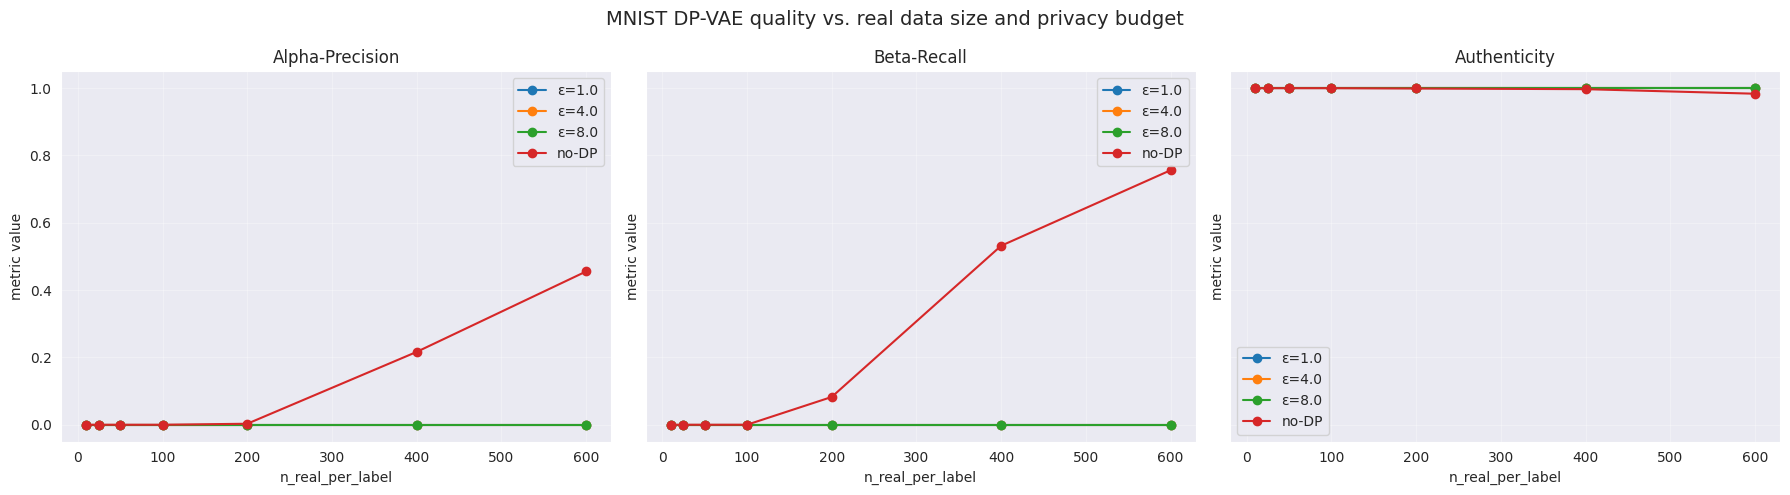

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
metric_cols = ["mean_alpha_precision", "mean_beta_recall", "mean_authenticity"]
titles = ["Alpha-Precision", "Beta-Recall", "Authenticity"]

for ax, col, title in zip(axes, metric_cols, titles):
    for eps_label in summary_df["eps_label"].unique():
        subset = summary_df[summary_df["eps_label"] == eps_label]
        ax.plot(subset["n_real_per_label"], subset[col], marker="o", label=eps_label)
    ax.set_title(title)
    ax.set_xlabel("n_real_per_label")
    ax.set_ylabel("metric value")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("MNIST DP-VAE quality vs. real data size and privacy budget", fontsize=14)
plt.tight_layout()
plt.show()

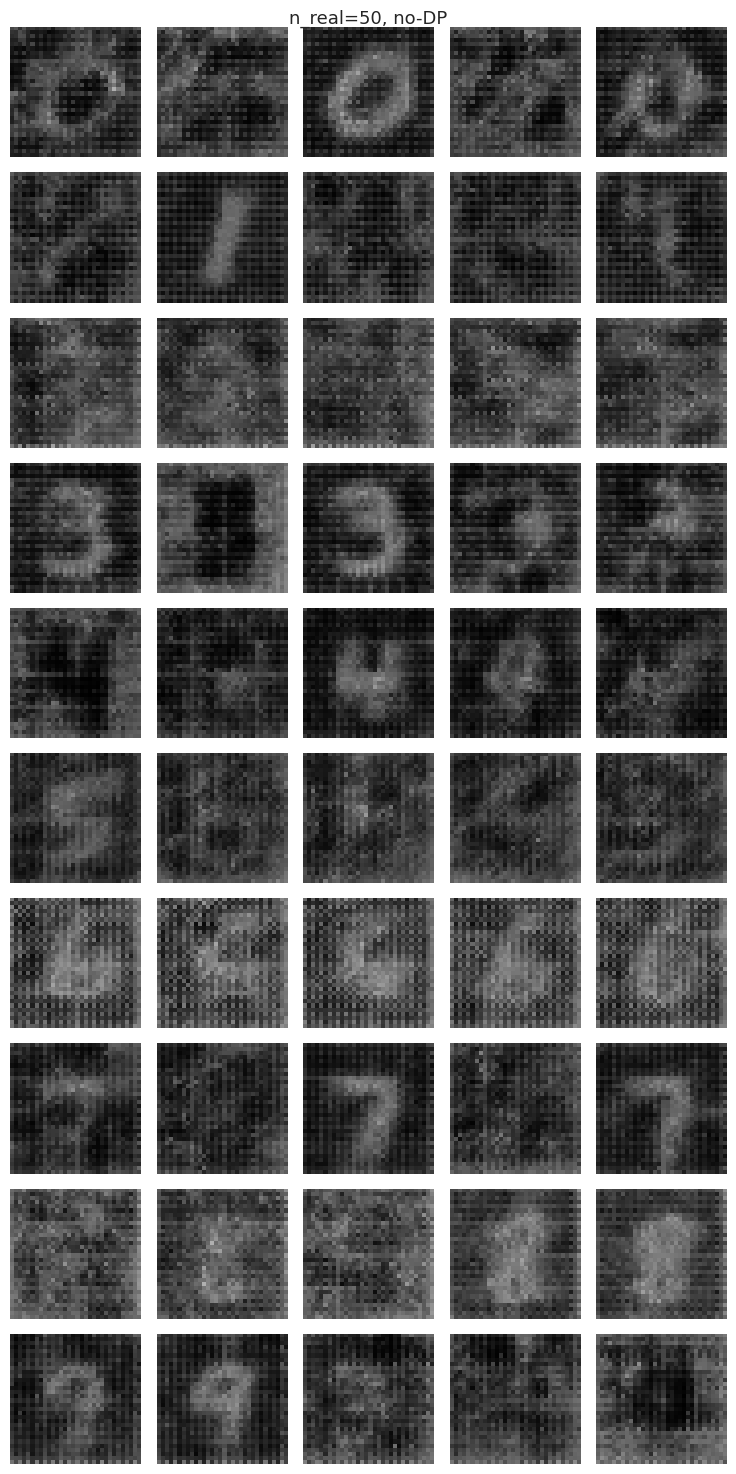

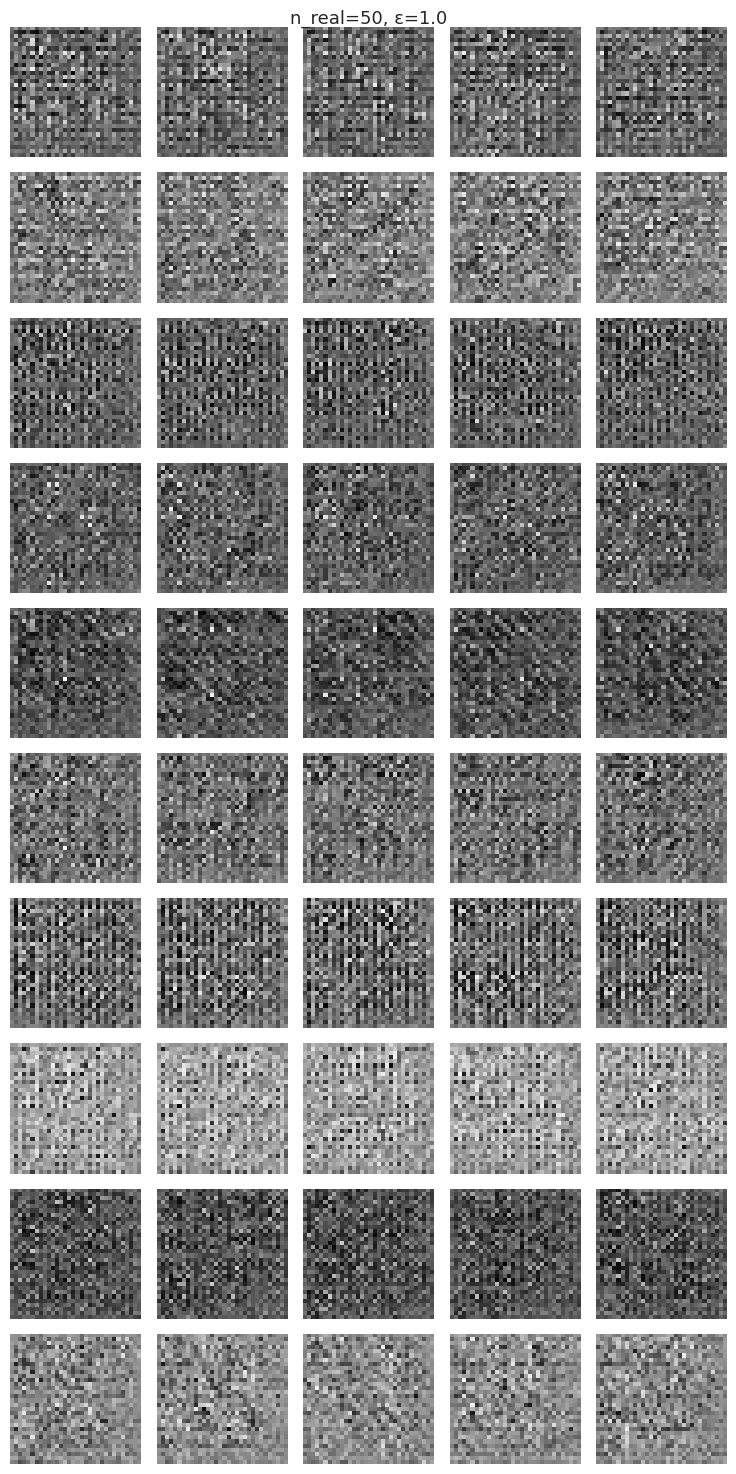

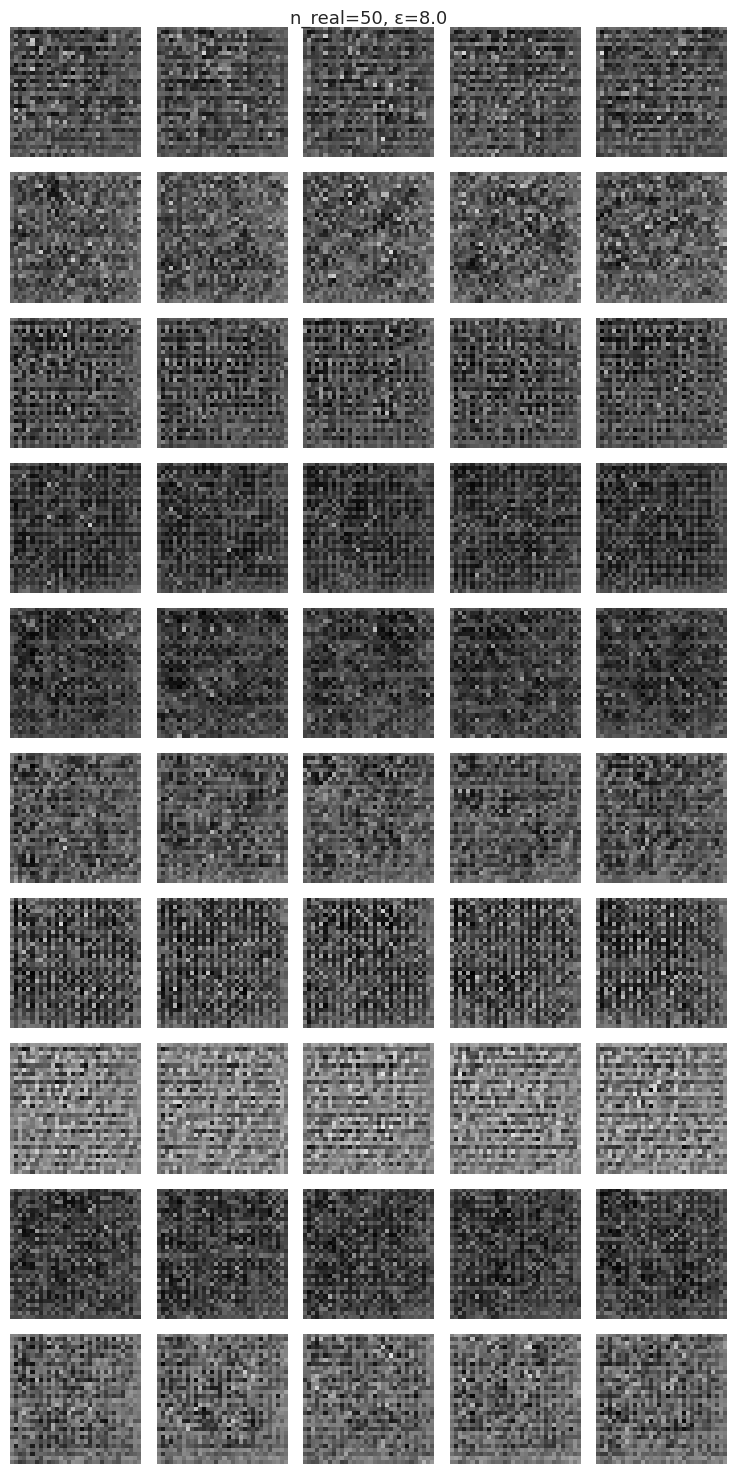

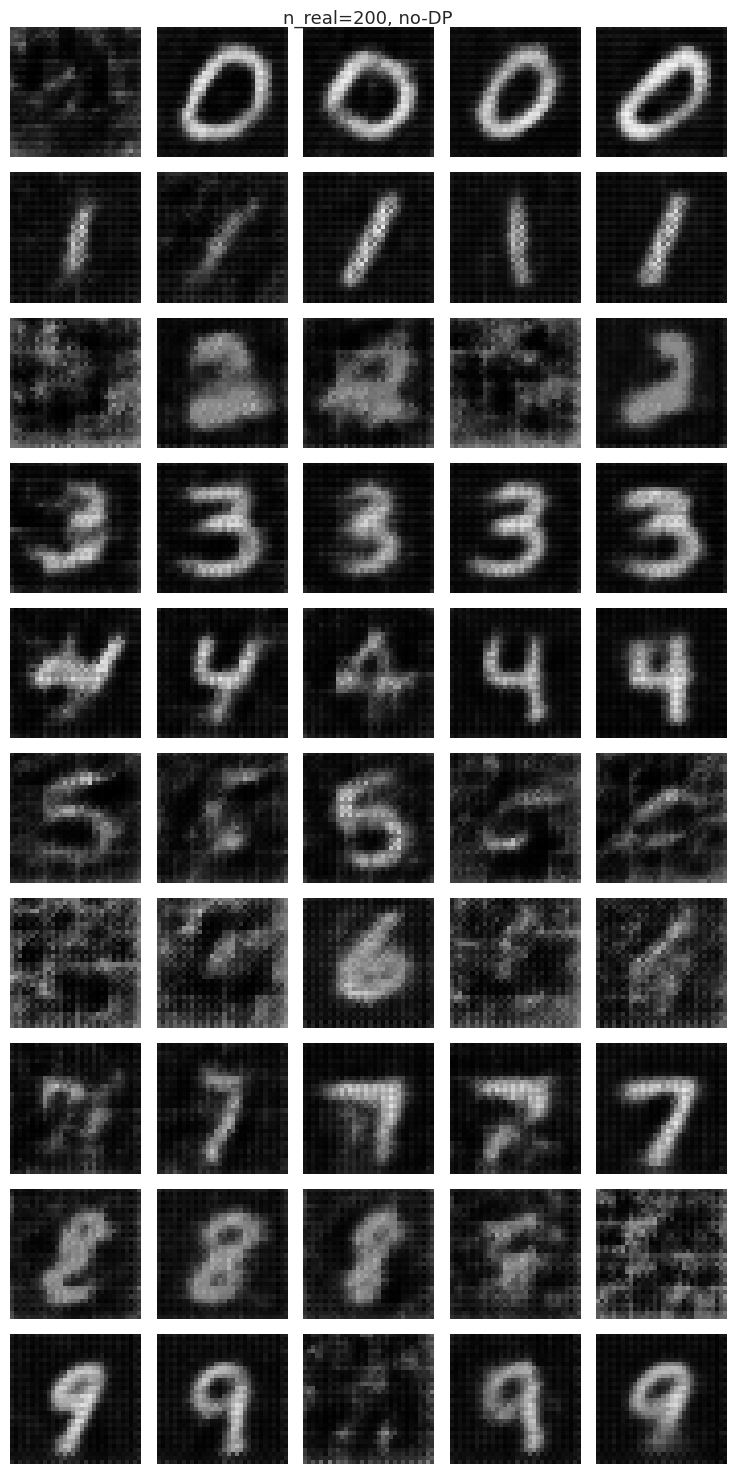

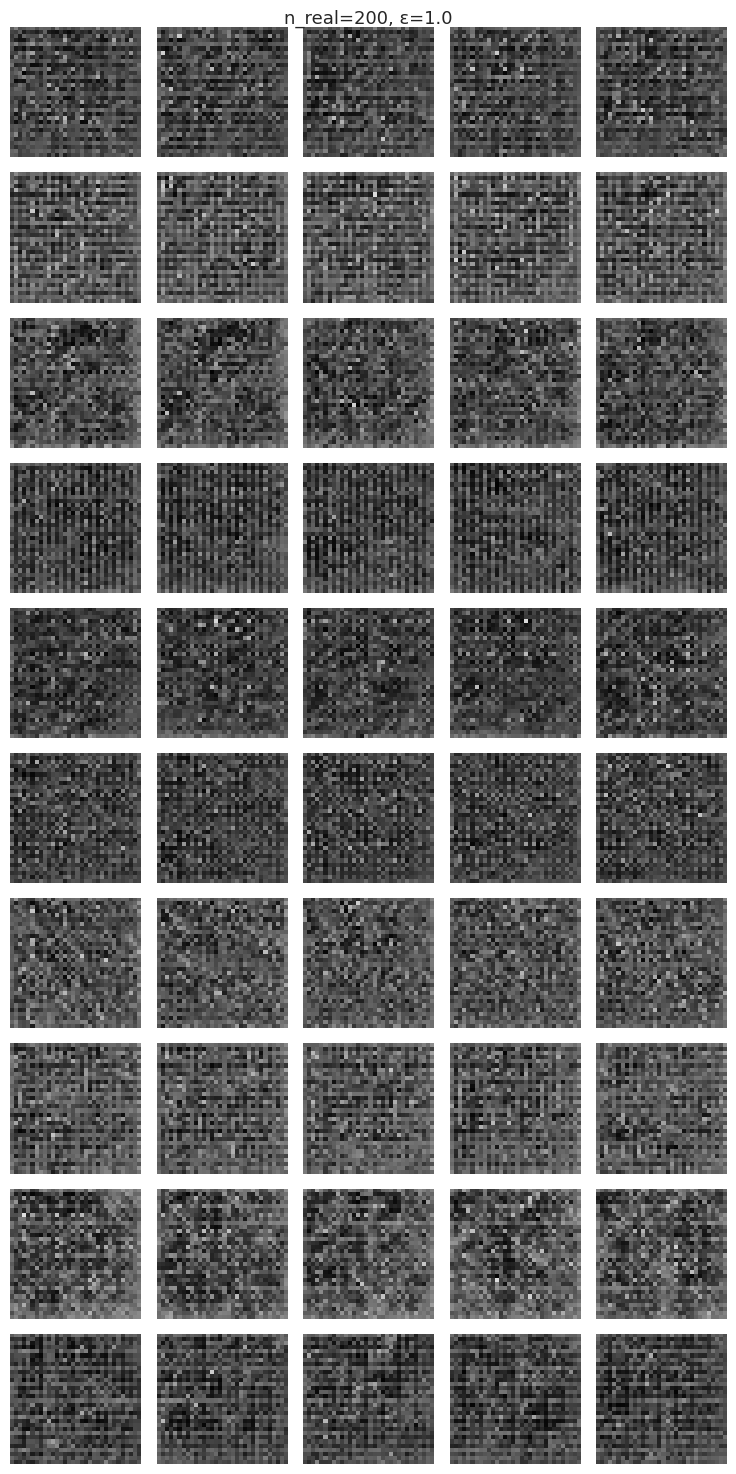

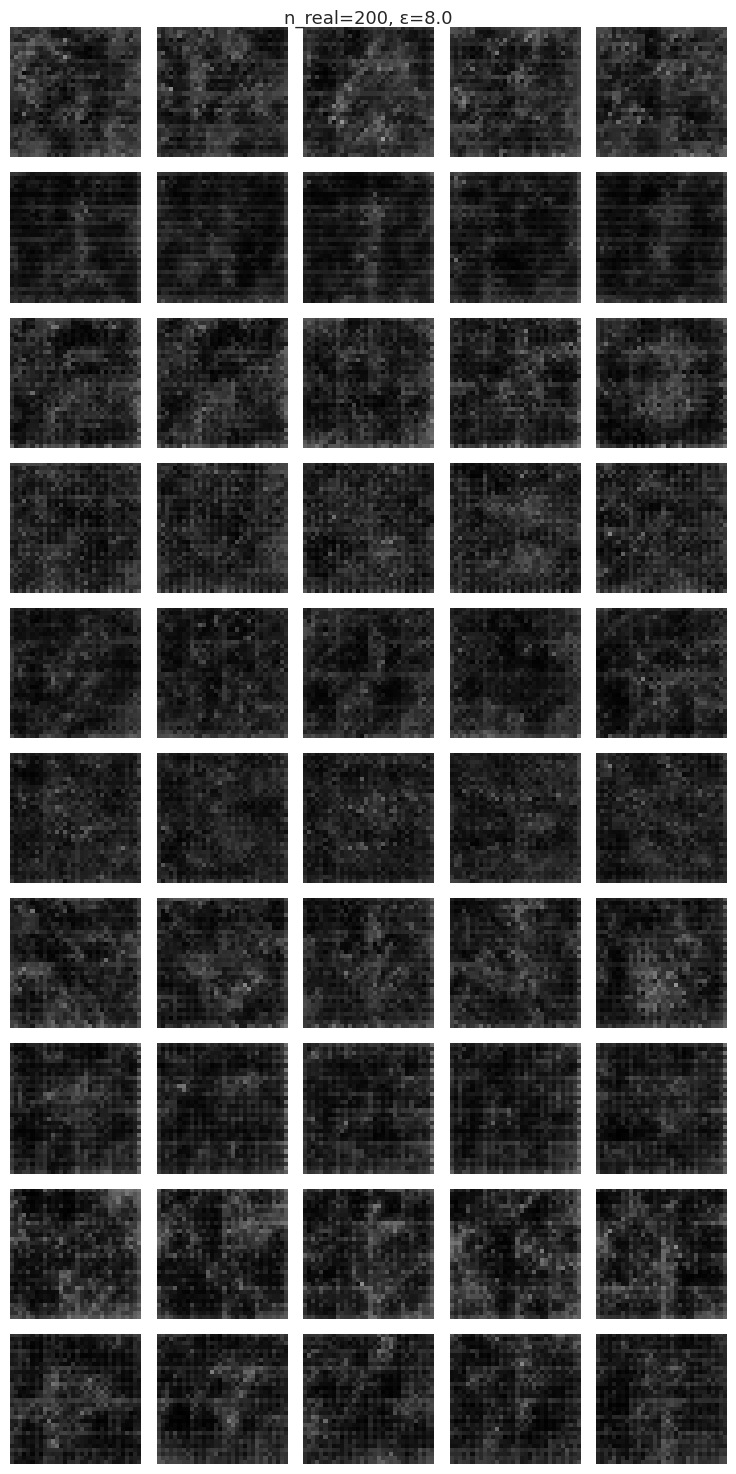

In [9]:
# Visual sample grid for a subset of (n_real, epsilon) combos
show_combos = [
    (50, None), (50, 1.0), (50, 8.0),
    (200, None), (200, 1.0), (200, 8.0),
]
# Filter to combos that were actually run
show_combos = [c for c in show_combos if c in synthetic_cache]
n_cols = 5  # samples per label to show

for n_real, target_eps in show_combos:
    syn_x, syn_y = synthetic_cache[(n_real, target_eps)]
    eps_str = "no-DP" if target_eps is None else f"ε={target_eps}"

    fig, axes = plt.subplots(10, n_cols, figsize=(n_cols * 1.5, 10 * 1.5))
    fig.suptitle(f"n_real={n_real}, {eps_str}", fontsize=13)

    for lbl in range(10):
        mask = syn_y == lbl
        lbl_imgs = syn_x[mask]
        for j in range(n_cols):
            ax = axes[lbl, j]
            if j < lbl_imgs.shape[0]:
                ax.imshow(lbl_imgs[j].squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(str(lbl), fontsize=11, rotation=0, labelpad=15)

    plt.tight_layout()
    plt.show()

In [10]:
out_csv = ROOT / "visual" / "outputs" / "mnist_syn_quality_check.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

if wandb_run is not None:
    wandb.log({"results_table": wandb.Table(dataframe=results_df)})
    wandb.log({"summary_table": wandb.Table(dataframe=summary_df.drop(columns=["eps_label"]))})
    wandb.finish()
    print("W&B run finished.")

Saved: <repo>/visual/outputs/mnist_syn_quality_check.csv


alpha_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁
authenticity,████████████████████████████████▁███████
beta_recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇█▁▁▁▁▁▁▁▁▁
label,▃▅▇▃▃▁▄▅▆▅▇▁▇█▂▄▇▁▃▃▃▇▂▃▅▆█▃▃▃█▃▄▆█▅▇▃▃▆
mean_alpha_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▁▁▁█▁▁▁
mean_authenticity,████████████████████▇███▁███
mean_beta_recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▆▁▁▁█▁▁▁
n_real_per_label,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▆▆▆█████
target_epsilon,▁▁██▁▃▃▅▅▅████▁▅▅█▁▁▅▅███▁▁▃▃▅▁▃█▁▁▃▅▅▅█
alpha_precision,0
authenticity,1


W&B run finished.
